## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split

In [2]:
# Load the data 
df = pd.read_csv('data/recruitmentdataset-2022.csv')
df.head()

,Id,gender,age,nationality,sport,ind-university_grade,ind-debateclub,ind-programming_exp,ind-international_exp,ind-entrepeneur_exp,ind-languages,ind-exact_study,ind-degree,company,decision
0,x8011e,female,24,German,Swimming,70,False,False,False,False,1,True,phd,A,True
1,x6077a,male,26,German,Golf,67,False,True,False,False,2,True,bachelor,A,False
2,x6006e,female,23,Dutch,Running,67,False,True,True,False,0,True,master,A,False
3,x2173b,male,24,Dutch,Cricket,70,False,True,False,False,1,True,master,A,True
4,x6241a,female,26,German,Golf,59,False,False,False,False,1,False,master,A,True


## Explanatory Analysis

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Id                     4000 non-null   object
 1   gender                 4000 non-null   object
 2   age                    4000 non-null   int64 
 3   nationality            4000 non-null   object
 4   sport                  4000 non-null   object
 5   ind-university_grade   4000 non-null   int64 
 6   ind-debateclub         4000 non-null   bool  
 7   ind-programming_exp    4000 non-null   bool  
 8   ind-international_exp  4000 non-null   bool  
 9   ind-entrepeneur_exp    4000 non-null   bool  
 10  ind-languages          4000 non-null   int64 
 11  ind-exact_study        4000 non-null   bool  
 12  ind-degree             4000 non-null   object
 13  company                4000 non-null   object
 14  decision               4000 non-null   bool  
dtypes: bool(6), int64(3),

In [21]:
df['gender'].value_counts()

gender
male      2127
female    1790
other       83
Name: count, dtype: int64

In [18]:
df['sport'].value_counts()

sport
Football    889
Swimming    689
Rugby       675
Tennis      443
Chess       365
Golf        323
Running     309
Cricket     307
Name: count, dtype: int64

In [5]:
df['ind-languages'].value_counts() # number of additional languages known by the candidates

ind-languages
1    1639
2    1349
0     676
3     336
Name: count, dtype: int64

<Axes: xlabel='company'>

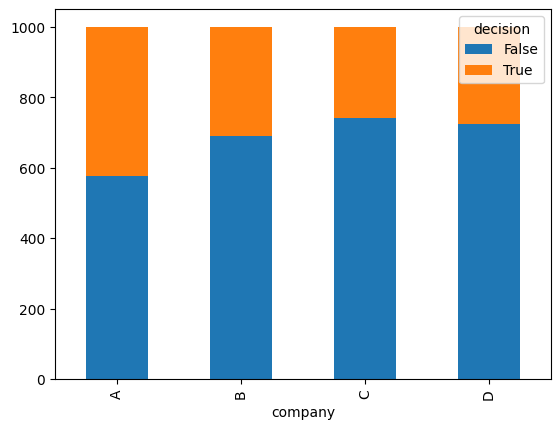

In [6]:
df.groupby(['company','decision']).size().unstack().plot(kind='bar', stacked=True)

<Axes: xlabel='gender'>

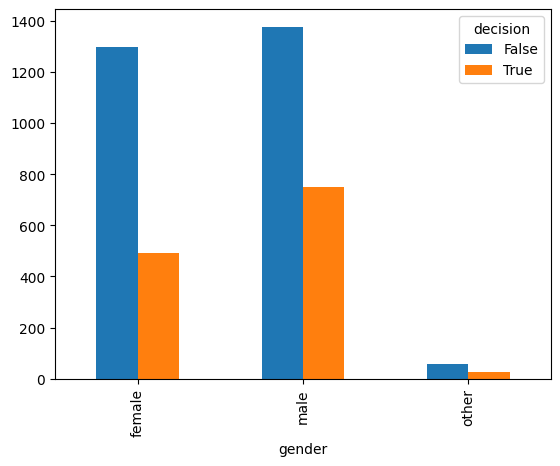

In [7]:
df.groupby(['gender', 'decision']).size().unstack().plot(kind='bar', stacked=False)

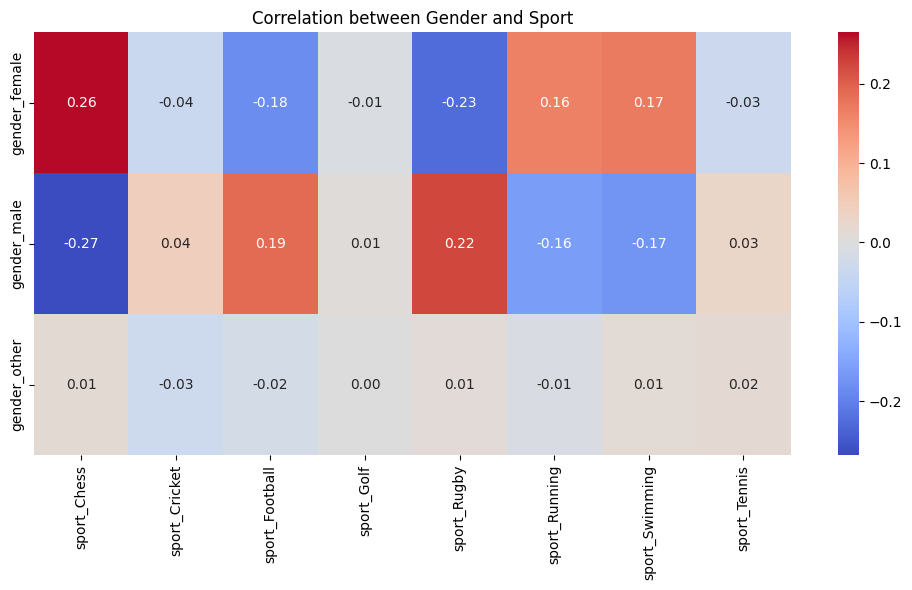

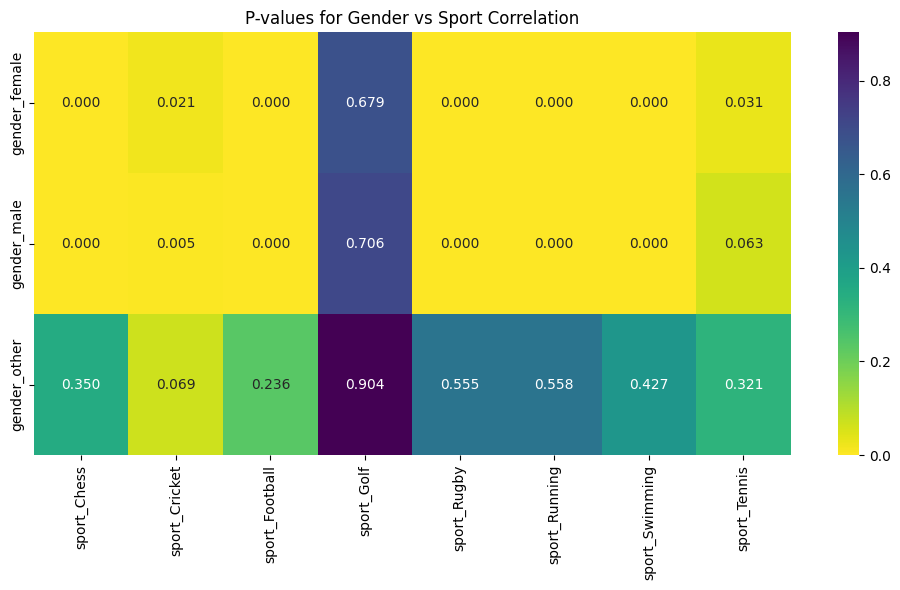

In [ ]:
# One-hot encode
df_encoded = pd.get_dummies(df[['gender', 'sport']])

# Identify columns
gender_cols = [col for col in df_encoded.columns if col.startswith('gender_')]
sport_cols = [col for col in df_encoded.columns if col.startswith('sport_')]

# Create empty DataFrames
corr_matrix = pd.DataFrame(index=gender_cols, columns=sport_cols)
pval_matrix = pd.DataFrame(index=gender_cols, columns=sport_cols)

# Compute correlation + p-values
for g in gender_cols:
    for s in sport_cols:
        r, p = pearsonr(df_encoded[g].astype(int), df_encoded[s].astype(int))
        corr_matrix.loc[g, s] = r
        pval_matrix.loc[g, s] = p

# Convert to float
corr_matrix = corr_matrix.astype(float)
pval_matrix = pval_matrix.astype(float)

# Plot correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt=".2f"
)
plt.title("Correlation between Gender and Sport")
plt.tight_layout()
plt.show()

# (Optional) Plot p-values heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    pval_matrix,
    annot=True,
    cmap='viridis_r',
    fmt=".3f"
)
plt.title("P-values for Gender vs Sport Correlation")
plt.tight_layout()
plt.show()

<Axes: >

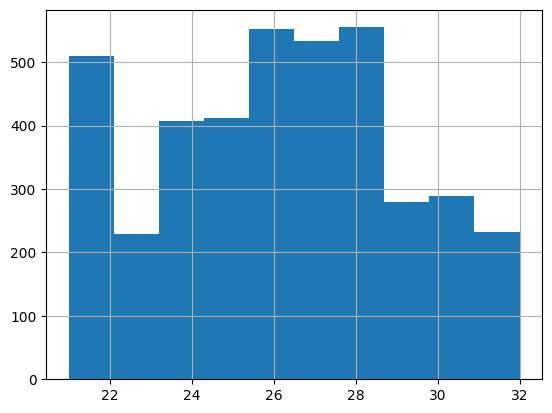

In [10]:
df['age'].hist()

## Baseline Model

In [ ]:
feature_names = [#'Id', # Id
                 "gender", # Gender - sensitive
                 'age', # age in years 
                 "nationality", # Nationality
                 'sport', # first/main sport listed on CV
                 'ind-university_grade', # University grade (percentage) of the canditate
                 "ind-debateclub", # whether candidate participated in debate club
                 "ind-programming_exp", # whether candidate has programming experience
                 'ind-international_exp', # whether candidate has international experience
                 "ind-entrepeneur_exp", # whether candidate has entrepeneur experience
                 "ind-languages", # Number of additional languages spoken fluently by candidate
                 'ind-exact_study', # whether candidate studied physics, engineering or other science-oriented study
                 'ind-degree', # highest completed degree. Phd, bachelor or master level
                 'company'] # The company the candidate applied to

target_name = "decision" # target value - wether the candidate got hired at the company or not

def data_processing(data, features, target_name:str):
    df = data
    ### Gender Filter
    df = df[df["gender"] != 'other'] # filter out 'other', to have binary gender

    ### Groups of interest
    sex = df["gender"].values

    ### Target
    df["target"] = df[target_name] # decision is target value
    target = df["target"].values
    df = df[features + ["target", target_name]] #we want to keep df before one_hot encoding to make Bias Analysis - probably not relevant with decision being binary to begin with
    df_processed = df[features].copy()
    cols = [ "gender", "nationality", "sport", "ind-degree", "company"]
    df_processed = pd.get_dummies(df_processed, prefix=None, prefix_sep='_', dummy_na=False, columns=cols, drop_first=False)
    df_processed = df_processed.drop(columns=["sport_Football", "gender_female", "nationality_Dutch", "ind-degree_bachelor", "company_A"])
    return df_processed, df, target, sex

data, data_original, target, group = data_processing(df, feature_names, target_name)

X_train, X_test, y_train, y_test, group_train, group_test = train_test_split(
    data, target, group, test_size=0.2, random_state=0)

C:\Users\Caroline Skovby\AppData\Local\Temp\ipykernel_41788\519979347.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["target"] = df[target_name] # decision is target value


In [10]:
X_train.columns

Index(['age', 'ind-university_grade', 'ind-debateclub', 'ind-programming_exp',
       'ind-international_exp', 'ind-entrepeneur_exp', 'ind-languages',
       'ind-exact_study', 'gender_male', 'nationality_Belgian',
       'nationality_German', 'sport_Chess', 'sport_Cricket', 'sport_Golf',
       'sport_Rugby', 'sport_Running', 'sport_Swimming', 'sport_Tennis',
       'ind-degree_master', 'ind-degree_phd', 'company_B', 'company_C',
       'company_D'],
      dtype='object')